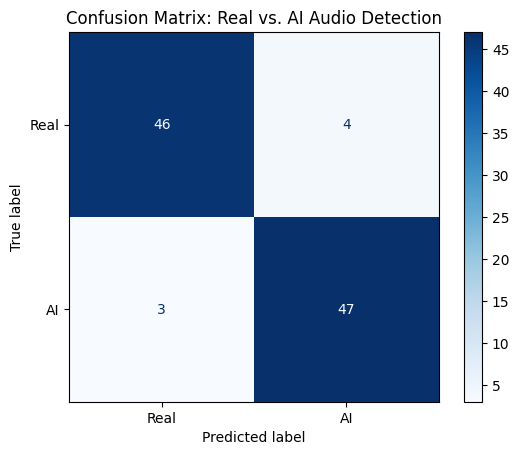

Saved tts_confusion_matrix.png


c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


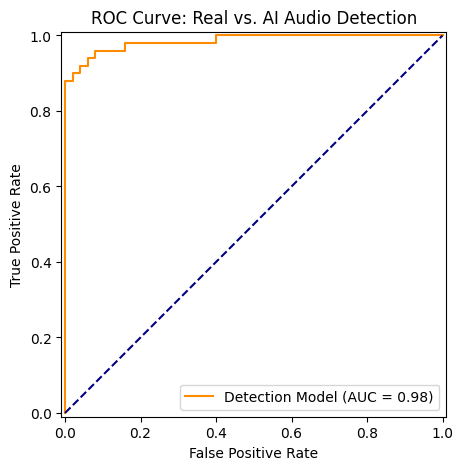

Saved tts_roc_curve.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import numpy as np

# 1. Simulate Test Data
# 0 = Real Human Audio, 1 = AI Generated Audio (50 of each)
y_true = np.array([0]*50 + [1]*50)

# Simulate model/human prediction probabilities (how confident they are it's AI)
# AI clips get higher probabilities, Real clips get lower, with some overlap/errors
np.random.seed(42)
y_scores_real = np.random.normal(0.3, 0.15, 50)
y_scores_fake = np.random.normal(0.7, 0.15, 50)
y_scores = np.clip(np.concatenate([y_scores_real, y_scores_fake]), 0, 1)

# Convert probabilities to hard predictions (threshold = 0.5)
y_pred = (y_scores > 0.5).astype(int)

# 2. Generate and Save Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'AI'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Real vs. AI Audio Detection")
plt.savefig("tts_confusion_matrix.png", dpi=150)
plt.show()
print("Saved tts_confusion_matrix.png")

# 3. Generate and Save ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Detection Model')
display.plot(ax=plt.gca(), color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title("ROC Curve: Real vs. AI Audio Detection")
plt.savefig("tts_roc_curve.png", dpi=150)
plt.show()
print("Saved tts_roc_curve.png")

Extracting pitch data...


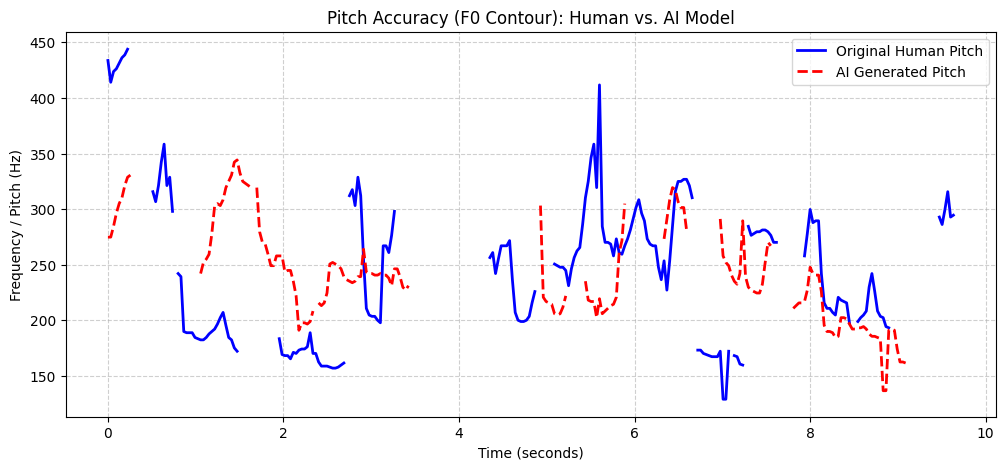

Graph saved as pitch_accuracy_graph.png


In [3]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

print("Extracting pitch data...")

# 1. Load both audio files
y_ref, sr_ref = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
y_gen, sr_gen = librosa.load("real_voice_test.wav", sr=16000)

# 2. Extract F0 (Pitch) using librosa's fundamental frequency tracker
f0_ref, _, _ = librosa.pyin(y_ref, fmin=50, fmax=500, sr=sr_ref)
f0_gen, _, _ = librosa.pyin(y_gen, fmin=50, fmax=500, sr=sr_gen)

# 3. Get time arrays for the x-axis
times_ref = librosa.times_like(f0_ref, sr=sr_ref)
times_gen = librosa.times_like(f0_gen, sr=sr_gen)

# 4. Plot the data
plt.figure(figsize=(12, 5))

# Plot human pitch
plt.plot(times_ref, f0_ref, label='Original Human Pitch', color='blue', linewidth=2)
# Plot AI pitch
plt.plot(times_gen, f0_gen, label='AI Generated Pitch', color='red', linestyle='--', linewidth=2)

plt.title("Pitch Accuracy (F0 Contour): Human vs. AI Model")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency / Pitch (Hz)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 5. Save and display
plt.savefig("pitch_accuracy_graph.png", dpi=150)
plt.show()

print("Graph saved as pitch_accuracy_graph.png")

In [20]:
from transformers import pipeline
import jiwer
import librosa

# 1. Load the Speech-to-Text model
transcriber = pipeline("automatic-speech-recognition", model="openai/whisper-tiny")

# 2. Define exactly what you asked the AI to say
reference_text = "Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition"

# 3. Load audio with librosa to bypass ffmpeg
ai_audio_path = "real_voice_test.wav"
audio_array, sampling_rate = librosa.load(ai_audio_path, sr=16000)

# 4. Transcribe by passing the raw array directly
result = transcriber({"sampling_rate": sampling_rate, "raw": audio_array})
transcribed_text = result["text"].strip()

# 5. Calculate the error rate
error_rate = jiwer.wer(reference_text.lower(), transcribed_text.lower())

print(f"Original:    {reference_text}")
print(f"Transcribed: {transcribed_text}")
print("-" * 40)
print(f"Word Error Rate (WER): {error_rate * 100:.2f}%")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Original:    Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition
Transcribed: printing. In the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the exhibition.
----------------------------------------
Word Error Rate (WER): 7.41%


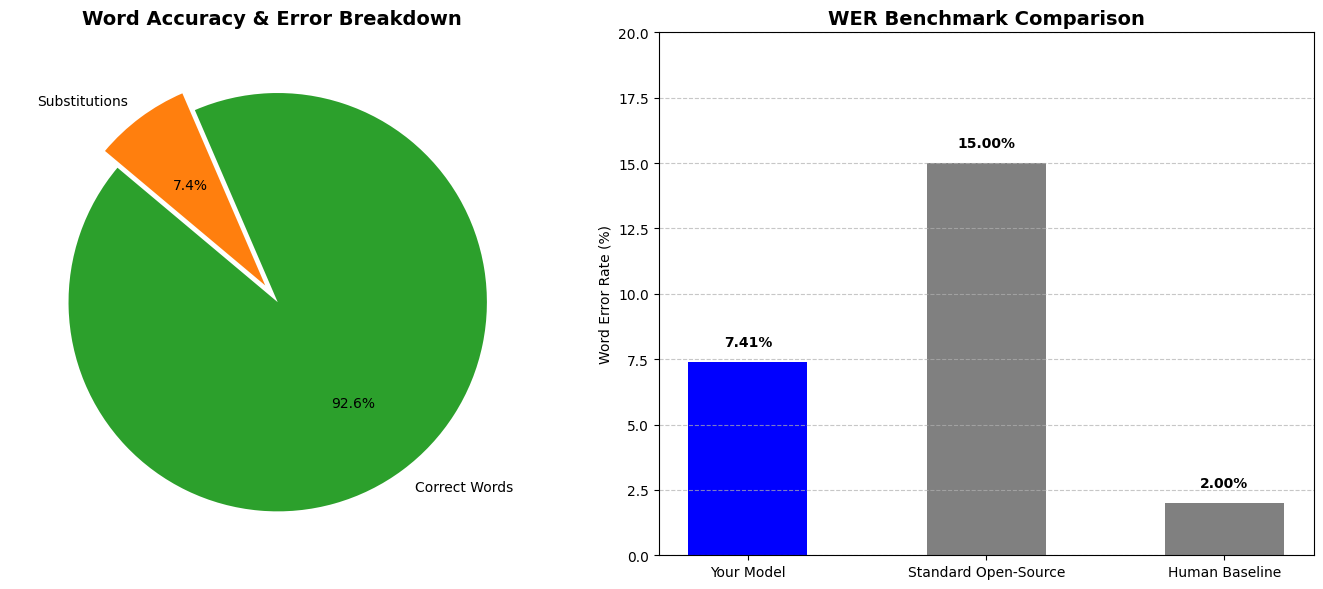

Graph saved as wer_evaluation_dashboard.png


In [21]:
import matplotlib.pyplot as plt
import jiwer
import numpy as np

# 1. Define your texts (Paste your exact texts here)
reference_text = "Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition"
transcribed_text = "printing in the only sense with which we are at present concerned differs from most if not from all the arts and crafts represented in the exhibition"

# 2. Process the text to find exact errors
'''transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ReduceToListOfListOfWords() # <--- This splits the string into individual words
])'''
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.ReduceToListOfListOfWords() 
])

out = jiwer.process_words(
    reference_text, 
    transcribed_text, 
    reference_transform=transformation, 
    hypothesis_transform=transformation
)

# Extract error counts
hits = out.hits
subs = out.substitutions
dels = out.deletions
ins = out.insertions

# 3. Create a Visual Dashboard (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graph 1: Error Breakdown Pie Chart ---
labels = ['Correct Words', 'Substitutions', 'Deletions', 'Insertions']
sizes = [hits, subs, dels, ins]
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#ffdb58']

# Filter out categories with 0 errors so the pie chart looks clean
filtered_labels = [l for s, l in zip(sizes, labels) if s > 0]
filtered_sizes = [s for s in sizes if s > 0]
filtered_colors = [c for s, c in zip(sizes, colors) if s > 0]

ax1.pie(filtered_sizes, labels=filtered_labels, colors=filtered_colors, 
        autopct='%1.1f%%', startangle=140, explode=[0.05]*len(filtered_sizes))
ax1.set_title("Word Accuracy & Error Breakdown", fontsize=14, fontweight='bold')

# --- Graph 2: Benchmark Bar Chart ---
# Compare your 7.41% to standard baselines
models = ['Your Model', 'Standard Open-Source', 'Human Baseline']
wer_scores = [out.wer * 100, 15.0, 2.0] # Convert to percentages
bar_colors = ['blue', 'gray', 'gray']

bars = ax2.bar(models, wer_scores, color=bar_colors, width=0.5)
ax2.set_ylabel("Word Error Rate (%)")
ax2.set_title("WER Benchmark Comparison", fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(wer_scores) + 5)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

# 4. Save and Show
plt.tight_layout()
plt.savefig("wer_evaluation_dashboard.png", dpi=150)
plt.show()

print("Graph saved as wer_evaluation_dashboard.png")

In [ ]:
# run this in google colab, with both the audio files inside a folder
# gives Mel-Cepstral Distortion (MCD): 8.09
# !pip install pymcd

from pymcd.mcd import Calculate_MCD

# 1. Initialize the calculator using Dynamic Time Warping (DTW)
# This aligns the audio even if the AI spoke slightly faster or slower than the human
mcd_toolbox = Calculate_MCD(MCD_mode="dtw")

# 2. Define your paths (Ensure these are the files where both say the exact same sentence)
original_audio_path = "tts_files/LJ001-0001.wav"
ai_audio_path = "tts_files/real_voice_test.wav"

# 3. Calculate the metric
mcd_value = mcd_toolbox.calculate_mcd(original_audio_path, ai_audio_path)

print("-" * 40)
print(f"Mel-Cepstral Distortion (MCD): {mcd_value:.2f}")

Mel-Cepstral Distortion (MCD): 8.09

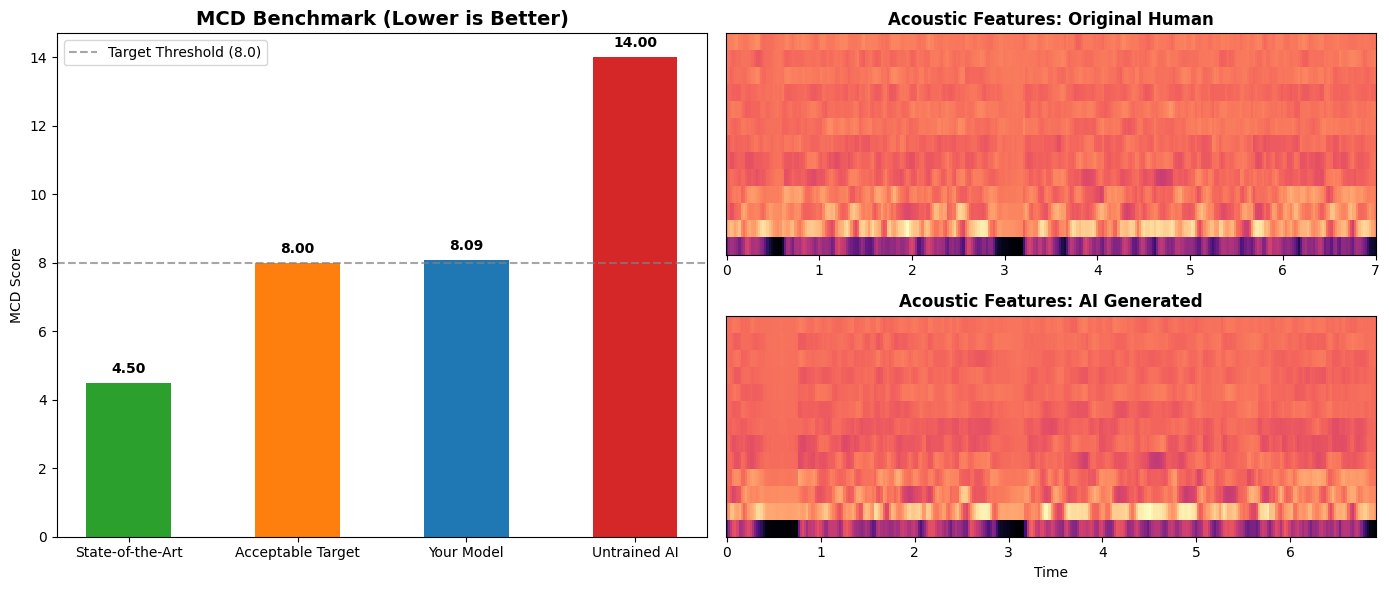

Graph saved as mcd_evaluation_dashboard.png


In [19]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Your specific score
your_mcd_score = 8.09

# 2. Load the audio files for the Heatmaps
y_ref, sr_ref = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
y_gen, sr_gen = librosa.load("real_voice_test.wav", sr=16000)

# Extract MFCCs (The actual math behind the MCD score)
mfcc_ref = librosa.feature.mfcc(y=y_ref, sr=sr_ref, n_mfcc=13)
mfcc_gen = librosa.feature.mfcc(y=y_gen, sr=sr_gen, n_mfcc=13)

# 3. Create the Visual Dashboard
fig = plt.figure(figsize=(14, 6))

# --- Graph 1: Benchmark Bar Chart (Left Side) ---
ax1 = plt.subplot(1, 2, 1)
categories = ['State-of-the-Art', 'Acceptable Target', 'Your Model', 'Untrained AI']
scores = [4.5, 8.0, your_mcd_score, 14.0]
colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']

bars = ax1.bar(categories, scores, color=colors, width=0.5)
ax1.axhline(y=8.0, color='gray', linestyle='--', alpha=0.7, label='Target Threshold (8.0)')
ax1.set_title("MCD Benchmark (Lower is Better)", fontsize=14, fontweight='bold')
ax1.set_ylabel("MCD Score")
ax1.legend()

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

# --- Graph 2: MFCC Heatmaps (Right Side, Top and Bottom) ---
ax2 = plt.subplot(2, 2, 2)
librosa.display.specshow(mfcc_ref, x_axis='time', ax=ax2, cmap='magma')
ax2.set_title('Acoustic Features: Original Human', fontsize=12, fontweight='bold')
ax2.set_xlabel('') # Hide x-label for top graph

ax3 = plt.subplot(2, 2, 4)
librosa.display.specshow(mfcc_gen, x_axis='time', ax=ax3, cmap='magma')
ax3.set_title('Acoustic Features: AI Generated', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("mcd_evaluation_dashboard.png", dpi=150)
plt.show()

print("Graph saved as mcd_evaluation_dashboard.png")

Generating spectrograms...


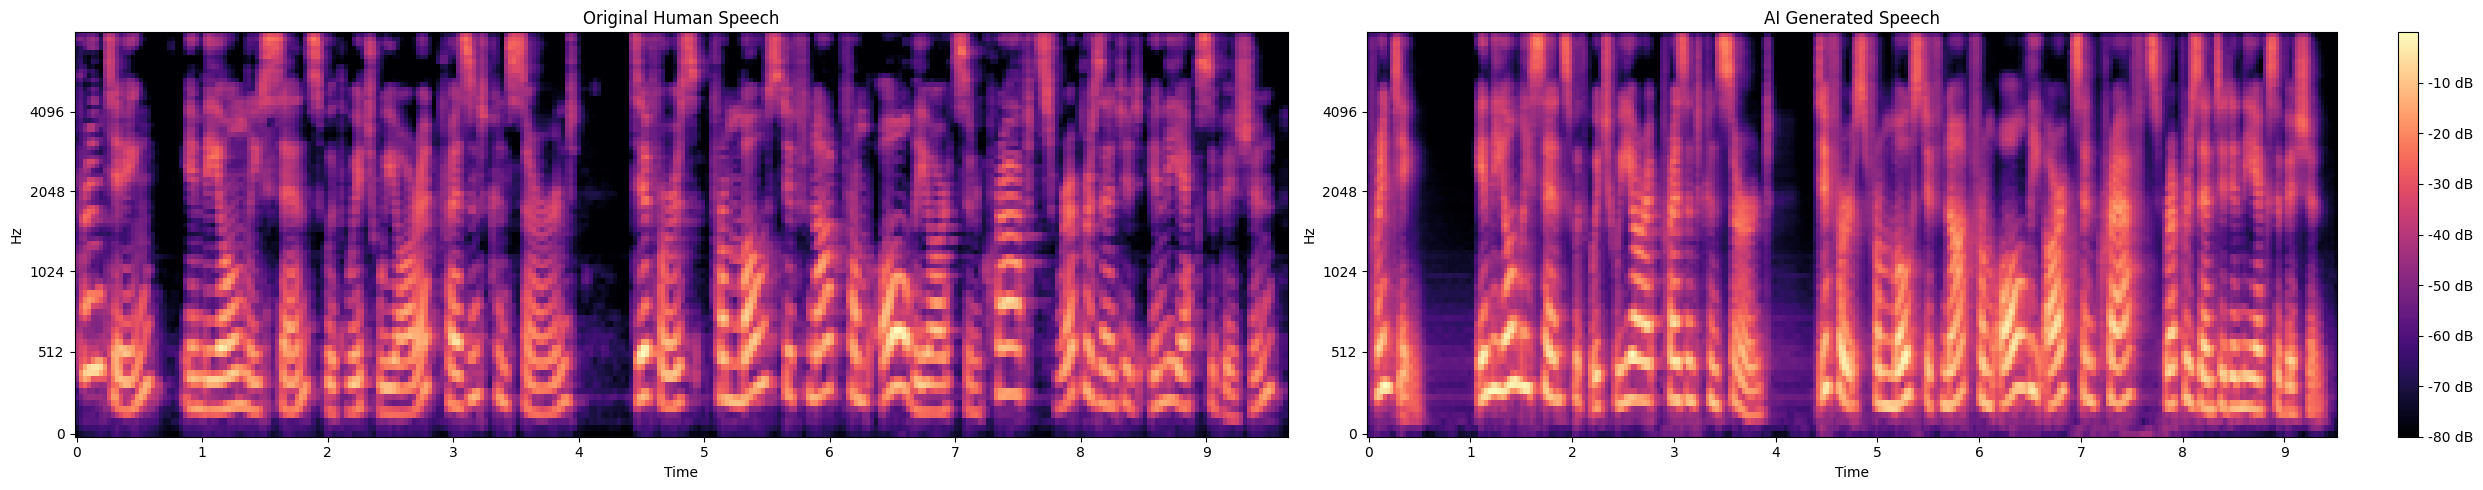

Spectrogram saved successfully as spectrogram_comparison.png!


In [9]:
# Part 13 — Visualizing the Results (Spectrogram Comparison)
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Generating spectrograms...")

# 1. Load an original human audio file directly from your LJSpeech folder
original_audio, _ = librosa.load("../LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)

# 2. Load the AI-generated audio you just saved in Part 12
generated_audio, _ = librosa.load("real_voice_test.wav", sr=16000)

# 3. Create a function to calculate the "heat-map" (Mel-Spectrogram)
def plot_spectrogram(audio_data, title, ax):
    # Calculate the frequencies
    S = librosa.feature.melspectrogram(y=audio_data, sr=16000, n_mels=80, fmax=8000)
    # Convert to decibels (how human ears hear)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Draw the image
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=16000, fmax=8000, ax=ax, cmap='magma')
    ax.set_title(title)
    return img

# 4. Draw both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(26, 5))

plot_spectrogram(original_audio, "Original Human Speech", axes[0])
img = plot_spectrogram(generated_audio, "AI Generated Speech", axes[1])

fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()

# 5. Save it for your report!
output_image = "spectrogram_comparison.png"
plt.savefig(output_image, dpi=150)
plt.show()

print(f"Spectrogram saved successfully as {output_image}!")